In [ ]:
import geopandas as gpd
import xarray as xr
from resplotlib import rpc

fp_zarr = r"https://storage.googleapis.com/dgds-data-public/gca/world_pop.zarr"
fp_geojson = r"../../data/01_areas/terschelling.geojson"

ds = xr.open_zarr(fp_zarr)
gdf_areas = gpd.read_file(fp_geojson)


def slice_zarr_bounds(
    ds: xr.Dataset,
    bounds: tuple[float, float, float, float],
) -> xr.Dataset:
    """Select stations within (min_lon, min_lat, max_lon, max_lat)."""
    min_lon, min_lat, max_lon, max_lat = bounds

    mask = (
        (ds.lon >= min_lon)
        & (ds.lon <= max_lon)
        & (ds.lat >= min_lat)
        & (ds.lat <= max_lat)
    )

    mask = mask.compute()

    return ds.where(mask, drop=True)


ds_clipped = slice_zarr_bounds(ds, gdf_areas.to_crs("EPSG:4326").total_bounds)

# Rename latitude and longitude coordinates to x and y
ds_clipped = ds_clipped.rename({"lat": "y", "lon": "x"})

ds_clipped = ds_clipped
ds_clipped


<xarray.Dataset> Size: 42kB
Dimensions:        (stations: 192)
Coordinates:
    continent      (stations) |S23 4kB b'Europe' b'Europe' ... b'Europe'
    country        (stations) |S40 8kB b'Netherlands' ... b'Netherlands'
    y              (stations) float64 2kB 53.41 53.41 53.41 ... 53.44 53.44
    x              (stations) float64 2kB 5.335 5.331 5.327 ... 5.494 5.485
    transect_geom  (stations) |S92 18kB b'LINESTRING (5.33519634742 53.411921...
    transect_id    (stations) |S15 3kB b'BOX_187_112_0' ... b'BOX_187_115_41'
Dimensions without coordinates: stations
Data variables:
    pop_10_m       (stations) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    pop_1_m        (stations) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    pop_5_m        (stations) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    pop_tot        (stations) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
Attributes: (12/21)
    AUTHOR:              Bondarenko, M., Kerr, D., Sorichetta, A. & Tatem, A.
    CITATION:            Bondarenko et al. (2020). Census/projection-disaggre...
    COMMENT:             This dataset is modified from the original Bondarenk...
    CRS:                 EPSG:4326
    Conventions:         CF-1.8
    DESCRIPTION:         The World Population dataset provides a global popul...
    ...                  ...
    SPATIAL_EXTENT:      [-180, -90, 180, 90]
    TAGS:                ['population distribution', 'population', 'populatio...
    TEMPORAL_EXTENT:     [2020]
    TITLE:               World Population
    TITLE_ABBREVIATION:  world_pop
    UNITS:

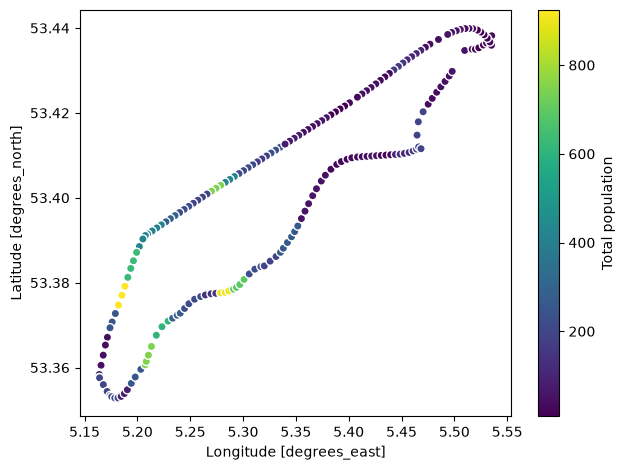

In [17]:
fig, ax = rpc.subplots()
ds_clipped.plot.scatter(x="x", y="y", hue="pop_tot", ax=ax)
rpc.show(fig)

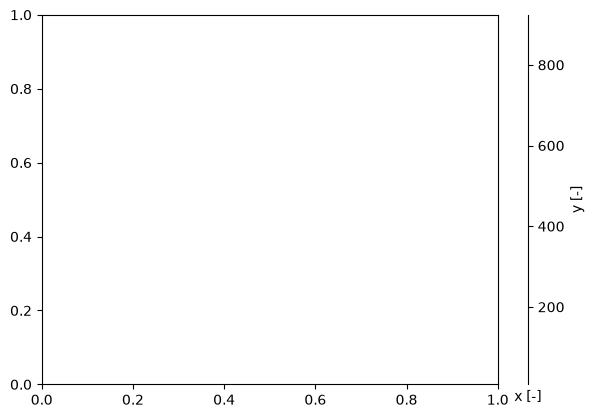

KeyboardInterrupt: 

In [23]:
fig, ax = rpc.subplots(1, 1, figsize=(8, 6))
rpc.scatter(
    ds_clipped,
    x="x",
    y="y",
    rescale_unit="m",
    hue="pop_tot",
    cmap="RdYlGn",
    add_colorbar=True,
    ax=ax,
)
rpc.show(fig)